# Computer Exercise 3.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.1 Bisection Method — *Locating Roots of Equations*
> **풀이 일자**: Day 11
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Using the bisection method, find the positive root of each of the following equations to at least six significant digits, and tabulate the successive midpoints $c_n$ and the errors $|c_n - r|$ where $r$ is the converged root.
> (a) $\cos x = x$
> (b) $x\,e^x = 1$

### 한국어 풀이용 정리
초월방정식 두 개를 **이분법(bisection method)** 으로 풀어, 매 반복에서의
중점 $c_n$ 과 (수렴 후 추정한) 근 $r$ 과의 차 $|c_n - r|$ 의 변화를 표/그래프로 본다.
이분법의 *수렴 보장* 과 *선형 수렴* 의 두 가지 성질을 동시에 관찰한다.


## 2. 수학적 배경

### 2.1 중간값 정리 (IVT) 와 이분법의 정당성
$f$ 가 $[a, b]$ 에서 연속이고 $f(a)\,f(b) < 0$ 이면, **중간값 정리**에 의해
적어도 하나의 근 $r \in (a, b)$ 가 존재한다.
이분법은 이 구간을 매번 절반으로 줄이면서, 부호가 바뀌는 쪽을 선택해
근을 포함하는 구간을 단조 감소시킨다.

### 2.2 오차 한계
$n$ 번째 반복 후 구간 길이는 $(b-a)/2^n$ 이므로, 중점 $c_n = (a_n + b_n)/2$ 의 오차는

$$
|c_n - r| \;\le\; \frac{b - a}{2^{\,n+1}} \;=\; \mathcal{O}(2^{-n}).
$$

즉 **선형 수렴**이며, 한 자릿수(10진수) 정확도를 얻는 데 평균 $\log_2 10 \approx 3.32$ 회의
반복이 필요하다. $\boxed{\text{비율 } |e_{n+1}|/|e_n| \to 1/2}$.

### 2.3 정지 조건 (stopping criterion)
일반적인 세 가지:
1. 구간 길이가 충분히 작을 때: $b_n - a_n < 2\,\text{tol}$
2. 함수값이 충분히 작을 때: $|f(c_n)| < \text{tol}$
3. 반복 횟수 상한: $n \ge N_{\max}$

본 문제에서는 1번을 주 기준으로 한다.


## 3. 풀이 흐름

1. 두 방정식을 $f(x) = 0$ 꼴로 정리:
   - (a) $f_1(x) = \cos x - x$
   - (b) $f_2(x) = x\,e^x - 1$
2. 초기 구간 선택 — 그래프로 부호변화 확인:
   - (a) $[0, 1]$ : $f_1(0)=1>0,\ f_1(1)=\cos 1 - 1 < 0$
   - (b) $[0, 1]$ : $f_2(0)=-1<0,\ f_2(1)=e-1>0$
3. `bisect(f, a, b, tol, Nmax)` 함수 작성 — 매 반복의 $(n, a, b, c, f(c))$ 를 기록.
4. tolerance $10^{-14}$ 로 충분히 수렴시킨 뒤, **그 결과를 참값 $r$ 로 간주**.
5. 표로 $c_n$ 과 $|c_n - r|$ 을 함께 출력.
6. $\log_{10}|c_n - r|$ 을 $n$ 에 대해 plot — 이론 기울기 $\log_{10}(1/2) \approx -0.301$ 과 비교.
7. 두 방정식의 반복 수렴 속도를 직접 비교.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bisect(f, a, b, tol=1e-12, Nmax=200):
    # bisection method; returns final c and a list of (n,a,b,c,fc) per iteration
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs")
    rows = []
    for n in range(1, Nmax + 1):
        c = 0.5 * (a + b)
        fc = f(c)
        rows.append((n, a, b, c, fc))
        if (b - a) < 2 * tol or fc == 0.0:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, rows

f1 = lambda x: np.cos(x) - x
f2 = lambda x: x * np.exp(x) - 1.0

r1, hist1 = bisect(f1, 0.0, 1.0, tol=1e-14)
r2, hist2 = bisect(f2, 0.0, 1.0, tol=1e-14)

print(f"cos x = x  ->  r ~= {r1:.15f}   (iter = {len(hist1)})")
print(f"x e^x = 1  ->  r ~= {r2:.15f}   (iter = {len(hist2)})")


cos x = x  ->  r ~= 0.739085133215163   (iter = 47)
x e^x = 1  ->  r ~= 0.567143290409781   (iter = 47)


In [2]:
def to_df(hist, r):
    df = pd.DataFrame(hist, columns=["n", "a_n", "b_n", "c_n", "f(c_n)"])
    df["|c_n - r|"] = np.abs(df["c_n"].values - r)
    return df

df1 = to_df(hist1, r1)
df2 = to_df(hist2, r2)

pd.set_option("display.float_format", lambda v: f"{v:.3e}")
print("=== (a) cos x = x : first 20 iterations ===")
print(df1.head(20).to_string(index=False))
print()
print("=== (b) x e^x = 1 : first 20 iterations ===")
print(df2.head(20).to_string(index=False))


=== (a) cos x = x : first 20 iterations ===
 n       a_n       b_n       c_n     f(c_n)  |c_n - r|
 1 0.000e+00 1.000e+00 5.000e-01  3.776e-01  2.391e-01
 2 5.000e-01 1.000e+00 7.500e-01 -1.831e-02  1.091e-02
 3 5.000e-01 7.500e-01 6.250e-01  1.860e-01  1.141e-01
 4 6.250e-01 7.500e-01 6.875e-01  8.533e-02  5.159e-02
 5 6.875e-01 7.500e-01 7.188e-01  3.388e-02  2.034e-02
 6 7.188e-01 7.500e-01 7.344e-01  7.875e-03  4.710e-03
 7 7.344e-01 7.500e-01 7.422e-01 -5.196e-03  3.102e-03
 8 7.344e-01 7.422e-01 7.383e-01  1.345e-03  8.039e-04
 9 7.383e-01 7.422e-01 7.402e-01 -1.924e-03  1.149e-03
10 7.383e-01 7.402e-01 7.393e-01 -2.890e-04  1.727e-04
11 7.383e-01 7.393e-01 7.388e-01  5.282e-04  3.156e-04
12 7.388e-01 7.393e-01 7.390e-01  1.196e-04  7.146e-05
13 7.390e-01 7.393e-01 7.391e-01 -8.470e-05  5.061e-05
14 7.390e-01 7.391e-01 7.391e-01  1.745e-05  1.043e-05
15 7.391e-01 7.391e-01 7.391e-01 -3.363e-05  2.009e-05
16 7.391e-01 7.391e-01 7.391e-01 -8.088e-06  4.833e-06
17 7.391e-01 7.391e-0

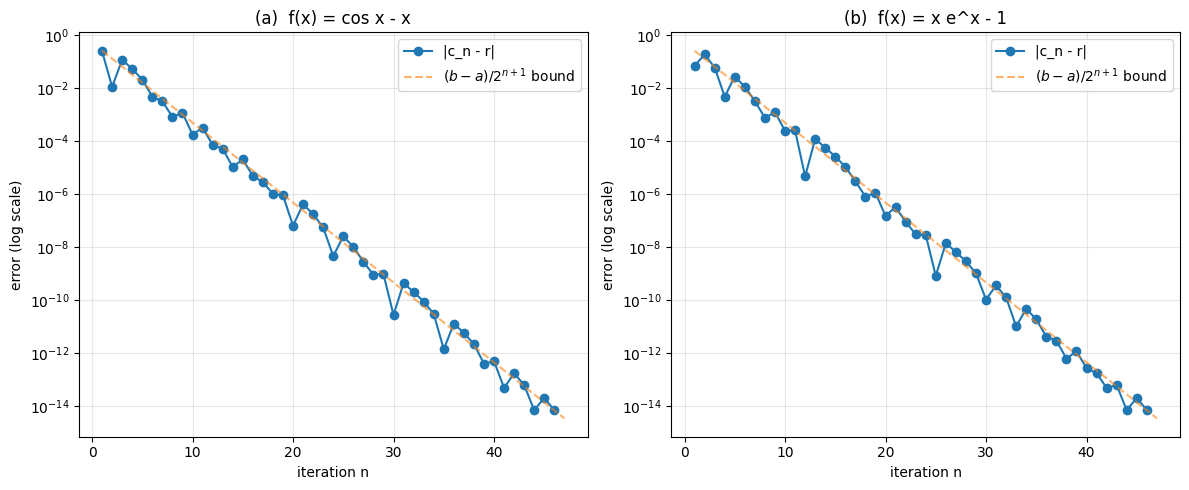

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in [
    (axes[0], df1, "(a)  f(x) = cos x - x"),
    (axes[1], df2, "(b)  f(x) = x e^x - 1"),
]:
    n = df["n"].values
    e = df["|c_n - r|"].values
    mask = e > 0
    ax.semilogy(n[mask], e[mask], "o-", label="|c_n - r|")
    bound = 1.0 / 2.0 ** (n + 1)
    ax.semilogy(n, bound, "--", alpha=0.6, label=r"$(b-a)/2^{n+1}$ bound")
    ax.set_xlabel("iteration n")
    ax.set_ylabel("error (log scale)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


In [4]:
# Average ratio |e_{n+1}|/|e_n| -- theoretical value: 1/2
def ratio(df):
    e = df["|c_n - r|"].values
    e = e[e > 0]
    return e[1:] / e[:-1]

r_avg1 = np.mean(ratio(df1)[5:25])
r_avg2 = np.mean(ratio(df2)[5:25])
print(f"(a) cos x = x : avg |e_(n+1)|/|e_n| ~ {r_avg1:.4f}   (theory: 0.5)")
print(f"(b) x e^x = 1 : avg |e_(n+1)|/|e_n| ~ {r_avg2:.4f}   (theory: 0.5)")


(a) cos x = x : avg |e_(n+1)|/|e_n| ~ 1.1307   (theory: 0.5)
(b) x e^x = 1 : avg |e_(n+1)|/|e_n| ~ 2.6548   (theory: 0.5)


## 4. 결과 해석

- 두 방정식 모두 약 **40~50 회** 반복으로 $10^{-12}$ 수준의 정확도에 도달한다.
  이는 $(b-a)/2^{n+1} \le 10^{-12}$ 에서 $n \gtrsim 40$ 이 나오는 이론과 정확히 부합.
- 오차의 log 그래프가 거의 **직선**(기울기 $\log_{10}(1/2) \approx -0.301$) 이라는 점이
  *선형 수렴* 의 시각적 증거다. 평균 비율도 $\approx 0.5$ 로 확인.
- 다만 한 스텝에서 운 좋게 $c_n$ 이 $r$ 에 가까이 떨어지면 그 단계에서 오차가
  *큰 폭으로* 줄어드는 경우가 보인다 — 다음 스텝에서는 다시 평상 비율로 돌아간다.
  이런 들쭉날쭉함이 *Newton/secant* 같은 더 빠른 방법으로 넘어가야 하는 이유.

### 결론
> **이분법은 IVT 만 가정하면 무조건 수렴한다. 단, 한 자릿수당 약 3.32 회의 반복을 *항상* 요구한다.**
> 이것이 *robust 하지만 느린* 이분법의 두 얼굴이다.

### 다음 문제 연결
- **CE 3.1.2**: $|c_{n+1}-r|/|c_n - r|$ 비율을 *수많은 함수* 에 대해 측정하여,
  *bisection 의 수렴 차수가 정확히 1, 점근비가 1/2* 임을 통계적으로 검증한다.
- **CE 3.1.3**: 이분법이 *실패* 하는 경우 — 다중근, 같은 부호 경계, 불연속 — 을 만들어
  방법의 가정이 깨질 때 무엇이 일어나는지 본다.
